In [20]:
import torch
print(torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

2.10.0+cu128
GPU available: True
GPU name: Tesla T4


In [21]:
import os

data_path = '/content/drive/MyDrive/chest_xray'

# Count images in each folder
for split in ['train', 'val', 'test']:
    for label in ['NORMAL', 'PNEUMONIA']:
        folder = os.path.join(data_path, split, label)
        count = len(os.listdir(folder))
        print(f"{split}/{label}: {count} images")

train/NORMAL: 1342 images
train/PNEUMONIA: 3876 images
val/NORMAL: 9 images
val/PNEUMONIA: 9 images
test/NORMAL: 234 images
test/PNEUMONIA: 390 images


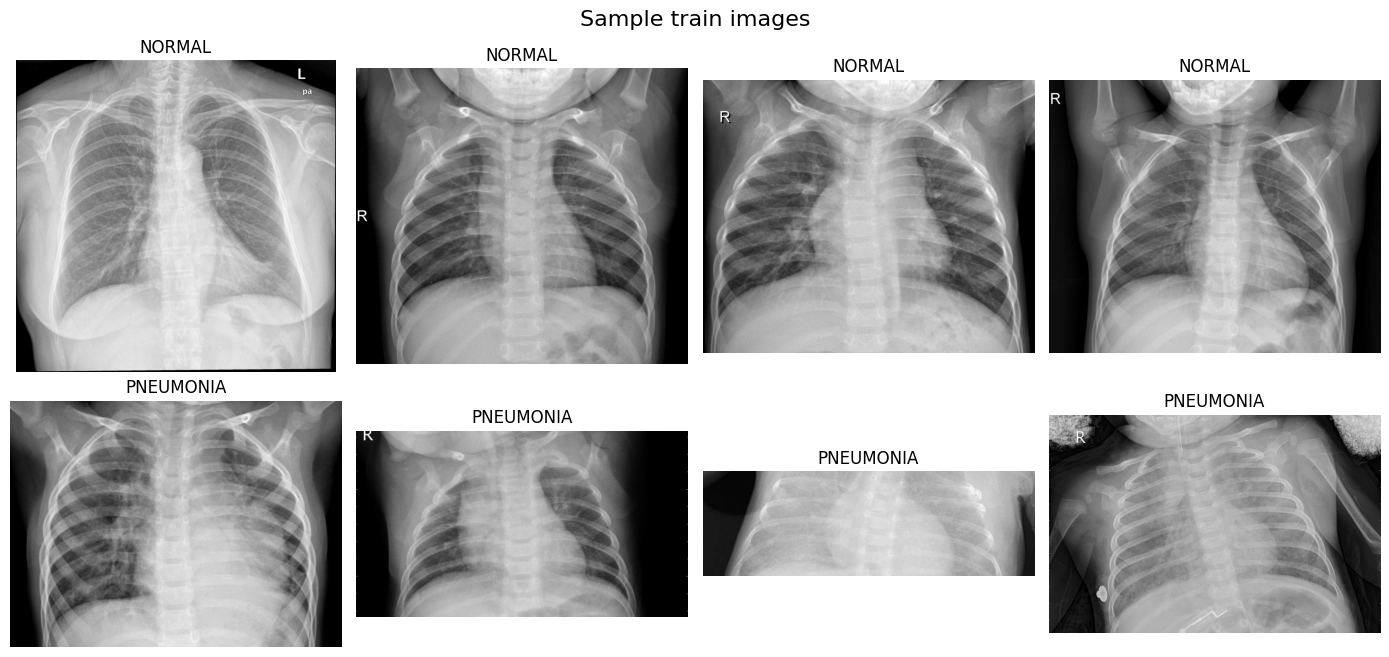

In [22]:
import matplotlib.pyplot as plt
import cv2
import os
import random

def show_samples(data_path, split='train'):
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    fig.suptitle(f'Sample {split} images', fontsize=16)

    for i, label in enumerate(['NORMAL', 'PNEUMONIA']):
        folder = os.path.join(data_path, split, label)
        images = random.sample(os.listdir(folder), 4)

        for j, img_name in enumerate(images):
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            axes[i][j].imshow(img, cmap='gray')
            axes[i][j].set_title(label)
            axes[i][j].axis('off')

    plt.tight_layout()
    plt.show()

show_samples(data_path)

In [23]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

# ── 1. Define Transforms ──────────────────────────────────────────
# Training transforms (with augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),         # resize every image to 224x224
    transforms.Grayscale(num_output_channels=3),  # convert to 3 channels
    transforms.RandomHorizontalFlip(),     # randomly flip image left-right
    transforms.RandomRotation(15),         # randomly rotate up to 15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # vary brightness/contrast
    transforms.ToTensor(),                 # convert image to PyTorch tensor
    transforms.Normalize(                  # normalize with ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test transforms (NO augmentation — just resize and normalize)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ── 2. Load the Dataset ───────────────────────────────────────────
data_path = '/content/drive/MyDrive/chest_xray'

train_dataset = datasets.ImageFolder(data_path + '/train', transform=train_transforms)
val_dataset   = datasets.ImageFolder(data_path + '/val',   transform=val_transforms)
test_dataset  = datasets.ImageFolder(data_path + '/test',  transform=val_transforms)

print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Val size:",   len(val_dataset))
print("Test size:",  len(test_dataset))

Classes: ['NORMAL', 'PNEUMONIA']
Train size: 5216
Val size: 16
Test size: 624


In [24]:
# ── 3. Fix Class Imbalance with WeightedRandomSampler ────────────
# Count how many images per class
class_counts = np.bincount(train_dataset.targets)
print(f"\nNORMAL images:    {class_counts[0]}")
print(f"PNEUMONIA images: {class_counts[1]}")

# Give higher weight to the minority class (NORMAL)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for label in train_dataset.targets]
sample_weights = torch.DoubleTensor(sample_weights)

# This sampler will balance the classes automatically during training
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("\nClass weights:", class_weights)
print("Sampler ready ✅")


NORMAL images:    1341
PNEUMONIA images: 3875

Class weights: [0.00074571 0.00025806]
Sampler ready ✅


In [25]:
# ── 4. Create DataLoaders ─────────────────────────────────────────
# DataLoader feeds batches of images to the model during training

train_loader = DataLoader(
    train_dataset,
    batch_size=32,        # process 32 images at a time
    sampler=sampler,      # use our balanced sampler
    num_workers=2,        # parallel data loading
    pin_memory=True       # faster GPU transfer
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,        # no need to shuffle val/test
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))
print("Test batches: ", len(test_loader))

Train batches: 163
Val batches:   1
Test batches:  20


In [26]:
# ── 5. Check one batch ────────────────────────────────────────────
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
# Should print: torch.Size([32, 3, 224, 224])
# Meaning: 32 images, 3 channels, 224x224 pixels

print("Batch labels:", labels)
# Should print: tensor([0, 1, 1, 0, ...]) — 0=NORMAL, 1=PNEUMONIA

print("Pixel value range:", images.min().item(), "to", images.max().item())

Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels: tensor([0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
        0, 1, 0, 1, 1, 1, 0, 1])
Pixel value range: -2.1179039478302 to 2.640000104904175


```
Step 5 → Defined how to transform raw images into model-ready tensors
            → Training gets augmentation (flips, rotations) for variety
            → Val/Test get NO augmentation (we want real performance)

Step 6 → Fixed the imbalance problem
            → NORMAL images get higher sampling weight
            → Model sees roughly equal NORMAL and PNEUMONIA during training

Step 7 → Created DataLoaders
            → Automatically feeds batches of 32 images to the model
            → Handles shuffling, parallel loading, GPU transfer

Step 8 → Verified everything works
            → Confirmed image shape is [32, 3, 224, 224]
            → Confirmed pixel values are normalized

In [27]:
import torch
import torch.nn as nn
from torchvision import models

def build_model(num_classes=2):
    # ── 1. Load pretrained ResNet-50 ──────────────────────────────
    model = models.resnet50(weights='IMAGENET1K_V1')

    # ── 2. Freeze all backbone layers ─────────────────────────────
    # We don't want to change what ResNet already learned from ImageNet
    for param in model.parameters():
        param.requires_grad = False

    # ── 3. Replace the final classification layer ──────────────────
    # ResNet-50's original final layer outputs 1000 classes (ImageNet)
    # We replace it with our own for 2 classes (NORMAL vs PNEUMONIA)
    in_features = model.fc.in_features  # this is 2048

    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),   # 2048 → 512
        nn.ReLU(),                      # activation function
        nn.Dropout(0.5),                # randomly drop 50% neurons (prevents overfitting)
        nn.Linear(512, num_classes)     # 512 → 2 (our classes)
    )

    return model

# ── 4. Build and move model to GPU ────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = build_model(num_classes=2)
model = model.to(device)  # move model to GPU

# ── 5. Verify the model ───────────────────────────────────────────
print("\nModel's final layer:")
print(model.fc)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")

Using device: cuda

Model's final layer:
Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=512, out_features=2, bias=True)
)

Total parameters:     24,558,146
Trainable parameters: 1,050,114
Frozen parameters:    23,508,032


In [28]:
# ── Loss Function ─────────────────────────────────────────────────
# CrossEntropyLoss is standard for classification
# We add class weights to handle imbalance
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# ── Optimizer ─────────────────────────────────────────────────────
# Only optimize the trainable parameters (our custom head)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001          # learning rate
)

# ── Learning Rate Scheduler ───────────────────────────────────────
# Reduces learning rate when validation loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # reduce when val loss stops going down
    patience=3,       # wait 3 epochs before reducing
    factor=0.1        # multiply LR by 0.1
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("Scheduler ready ✅")

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Scheduler ready ✅


```
Step 9 → Built the model
            → Loaded ResNet-50 pretrained on ImageNet (already knows edges, shapes, textures)
            → Froze all 23 million backbone parameters (don't touch what's already good)
            → Replaced final layer with our custom head (learns our 2 classes)
            → Only ~1 million parameters need training — much faster!

Step 10 → Defined how the model learns
            → CrossEntropyLoss → measures how wrong the prediction is
            → Adam Optimizer → adjusts weights to reduce the loss
            → Scheduler → slows down learning when progress stalls

In [29]:
import time

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10):

    best_val_accuracy = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        start_time = time.time()

        # ── TRAINING PHASE ────────────────────────────────────────
        model.train()  # set model to training mode
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            # Move data to GPU
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass — get predictions
            optimizer.zero_grad()          # clear old gradients
            outputs = model(images)        # predict
            loss = criterion(outputs, labels)  # calculate loss

            # Backward pass — update weights
            loss.backward()                # calculate gradients
            optimizer.step()               # update weights

            # Track accuracy
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

            # Print progress every 50 batches
            if (batch_idx + 1) % 50 == 0:
                print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

        # ── VALIDATION PHASE ──────────────────────────────────────
        model.eval()  # set model to evaluation mode
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():  # no gradient calculation needed
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        # ── CALCULATE METRICS ─────────────────────────────────────
        train_loss_avg = train_loss / len(train_loader)
        val_loss_avg   = val_loss   / len(val_loader)
        train_acc = 100. * train_correct / train_total
        val_acc   = 100. * val_correct   / val_total
        epoch_time = time.time() - start_time

        # Save to history
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # Update scheduler
        scheduler.step(val_loss_avg)

        # Save best model
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"  💾 Best model saved! Val Accuracy: {val_acc:.2f}%")

        # Print epoch summary
        print(f"\nEpoch {epoch+1}/{epochs} — {epoch_time:.1f}s")
        print(f"  Train Loss: {train_loss_avg:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_acc:.2f}%")
        print("-" * 55)

    print(f"\n✅ Training complete! Best Val Accuracy: {best_val_accuracy:.2f}%")
    return history

In [30]:
# Train for 10 epochs first
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=10
)

  Epoch 1 | Batch 50/163 | Loss: 0.2549
  Epoch 1 | Batch 100/163 | Loss: 0.2058
  Epoch 1 | Batch 150/163 | Loss: 0.1449
  💾 Best model saved! Val Accuracy: 87.50%

Epoch 1/10 — 135.3s
  Train Loss: 0.2984 | Train Acc: 82.00%
  Val Loss:   0.2009 | Val Acc:   87.50%
-------------------------------------------------------
  Epoch 2 | Batch 50/163 | Loss: 0.1474
  Epoch 2 | Batch 100/163 | Loss: 0.1941
  Epoch 2 | Batch 150/163 | Loss: 0.0679

Epoch 2/10 — 133.4s
  Train Loss: 0.2133 | Train Acc: 88.65%
  Val Loss:   0.1796 | Val Acc:   87.50%
-------------------------------------------------------
  Epoch 3 | Batch 50/163 | Loss: 0.1634
  Epoch 3 | Batch 100/163 | Loss: 0.3060
  Epoch 3 | Batch 150/163 | Loss: 0.3029
  💾 Best model saved! Val Accuracy: 100.00%

Epoch 3/10 — 138.2s
  Train Loss: 0.1659 | Train Acc: 91.24%
  Val Loss:   0.1787 | Val Acc:   100.00%
-------------------------------------------------------
  Epoch 4 | Batch 50/163 | Loss: 0.1306
  Epoch 4 | Batch 100/163 | L

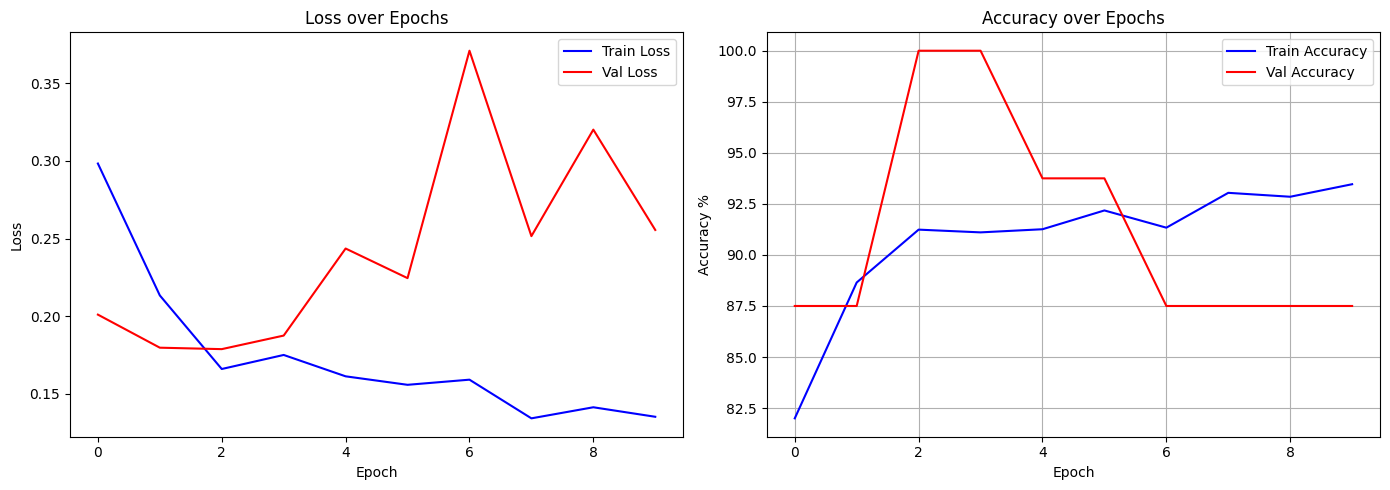

In [31]:
import matplotlib.pyplot as plt

def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curve
    axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
    axes[0].plot(history['val_loss'],   label='Val Loss',   color='red')
    axes[0].set_title('Loss over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()


    # Accuracy curve
    axes[1].plot(history['train_acc'], label='Train Accuracy', color='blue')
    axes[1].plot(history['val_acc'],   label='Val Accuracy',   color='red')
    axes[1].set_title('Accuracy over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy %')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)

```
Step 11 → The training loop
            → Forward pass  : model makes prediction
            → Loss          : measures how wrong it was
            → Backward pass : calculates how to fix the weights
            → Optimizer     : actually updates the weights
            → Repeats this for every batch, every epoch

Step 12 → Kicks off the actual training
            → 10 epochs = model sees all training data 10 times
            → Best model is automatically saved

Step 13 → Plots loss and accuracy curves
            → You can visually see if model is learning
            → If val loss goes UP while train loss goes DOWN = overfitting

In [32]:
# ── Unfreeze Layer4 of ResNet (Phase 2 fine-tuning) ───────────────
for name, param in model.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True

# smaller learning rate
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001   # 10x smaller than before
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.1
)

# Count newly trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters now: {trainable:,}")
print("Fine-tuning ready ✅")

Trainable parameters now: 16,014,850
Fine-tuning ready ✅


  Epoch 1 | Batch 50/163 | Loss: 0.1357
  Epoch 1 | Batch 100/163 | Loss: 0.1396
  Epoch 1 | Batch 150/163 | Loss: 0.0695
  💾 Best model saved! Val Accuracy: 100.00%

Epoch 1/5 — 133.5s
  Train Loss: 0.1207 | Train Acc: 93.94%
  Val Loss:   0.1740 | Val Acc:   100.00%
-------------------------------------------------------
  Epoch 2 | Batch 50/163 | Loss: 0.0508
  Epoch 2 | Batch 100/163 | Loss: 0.0262
  Epoch 2 | Batch 150/163 | Loss: 0.0351

Epoch 2/5 — 134.4s
  Train Loss: 0.0689 | Train Acc: 97.05%
  Val Loss:   0.0561 | Val Acc:   100.00%
-------------------------------------------------------
  Epoch 3 | Batch 50/163 | Loss: 0.0219
  Epoch 3 | Batch 100/163 | Loss: 0.1706
  Epoch 3 | Batch 150/163 | Loss: 0.0066

Epoch 3/5 — 134.2s
  Train Loss: 0.0547 | Train Acc: 97.24%
  Val Loss:   0.4561 | Val Acc:   75.00%
-------------------------------------------------------
  Epoch 4 | Batch 50/163 | Loss: 0.0015
  Epoch 4 | Batch 100/163 | Loss: 0.0824
  Epoch 4 | Batch 150/163 | Loss:

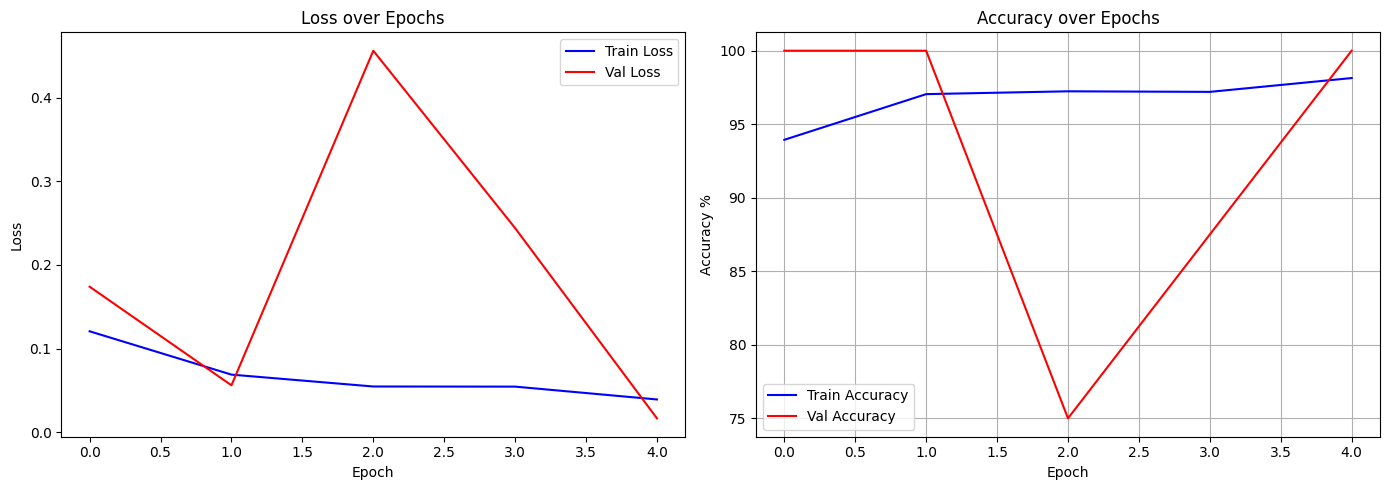

In [33]:
history2 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=5
)

# Plot the fine-tuning curves
plot_history(history2)

Before (Phase 1):
  → Only our custom head was trainable
  → ResNet backbone was completely frozen
  → Model learned: "how to map ResNet features to our 2 classes"

Now (Phase 2 Fine-tuning):
  → Layer4 (deepest ResNet layer) is now unfrozen too
  → It can now adapt its features specifically for X-rays
  → Much smaller LR (0.0001) so we don't destroy learned features
  → This typically pushes accuracy up another 1-3%

In [36]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)  # convert to probabilities
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

# Run evaluation
preds, labels, probs = evaluate_model(model, test_loader)

# Print classification report
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(
    labels, preds,
    target_names=['NORMAL', 'PNEUMONIA']
))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      NORMAL       0.92      0.84      0.88       234
   PNEUMONIA       0.91      0.95      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.90      0.90       624
weighted avg       0.91      0.91      0.91       624



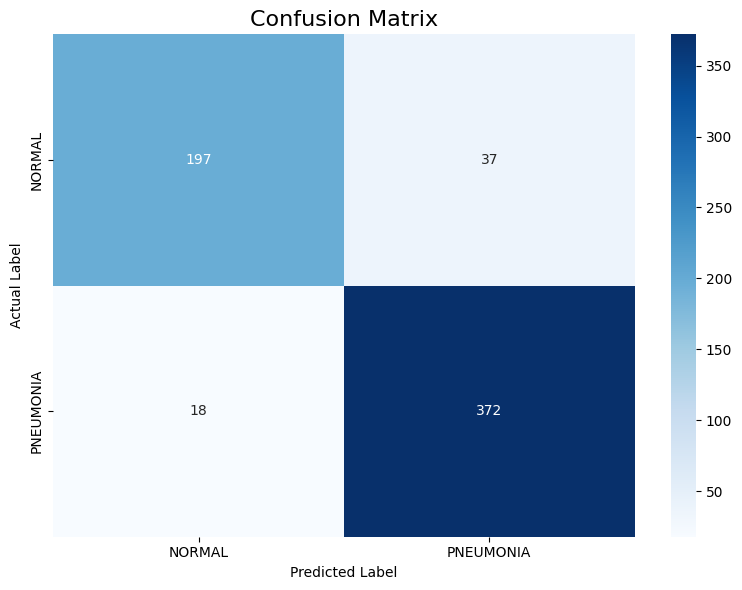

True Negatives  (NORMAL   → NORMAL):    197
False Positives (NORMAL   → PNEUMONIA): 37  ← wrongly flagged as sick
False Negatives (PNEUMONIA→ NORMAL):    18  ← missed pneumonia cases!
True Positives  (PNEUMONIA→ PNEUMONIA): 372


In [37]:
def plot_confusion_matrix(labels, preds):
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,        # show numbers inside boxes
        fmt='d',           # integer format
        cmap='Blues',      # blue color scheme
        xticklabels=['NORMAL', 'PNEUMONIA'],
        yticklabels=['NORMAL', 'PNEUMONIA']
    )
    plt.title('Confusion Matrix', fontsize=16)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    # Print what each box means
    tn, fp, fn, tp = cm.ravel()
    print(f"True Negatives  (NORMAL   → NORMAL):    {tn}")
    print(f"False Positives (NORMAL   → PNEUMONIA): {fp}  ← wrongly flagged as sick")
    print(f"False Negatives (PNEUMONIA→ NORMAL):    {fn}  ← missed pneumonia cases!")
    print(f"True Positives  (PNEUMONIA→ PNEUMONIA): {tp}")

plot_confusion_matrix(labels, preds)

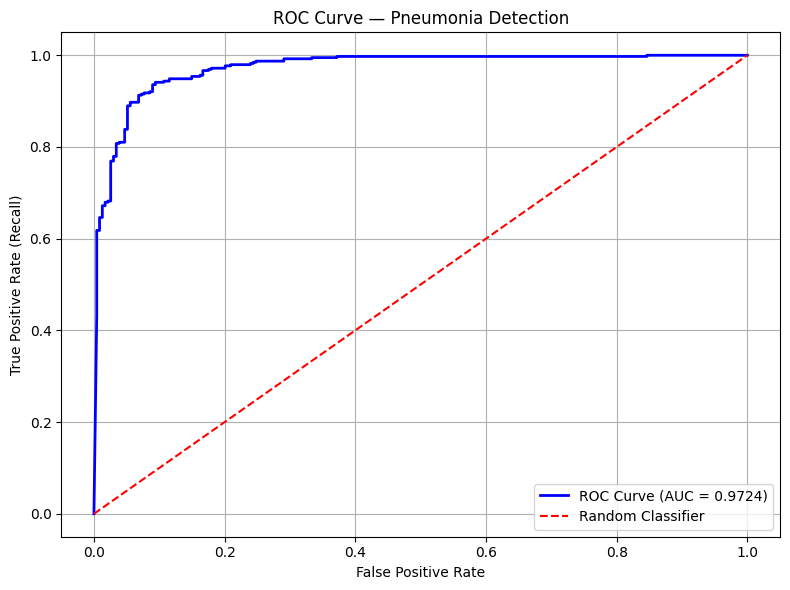


AUC Score: 0.9724
Excellent model! 🎉


In [38]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(labels, probs):
    # Get probability of PNEUMONIA class (index 1)
    pneumonia_probs = probs[:, 1]

    fpr, tpr, thresholds = roc_curve(labels, pneumonia_probs)
    auc_score = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', linewidth=2,
             label=f'ROC Curve (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='red',
             linestyle='--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('ROC Curve — Pneumonia Detection')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"\nAUC Score: {auc_score:.4f}")
    if auc_score > 0.97:
        print("Excellent model! 🎉")
    elif auc_score > 0.90:
        print("Very good model! ✅")
    else:
        print("Good model, room to improve.")

plot_roc_curve(labels, probs)

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None

        # Register hooks to capture activations and gradients
        target_layer.register_forward_hook(self.save_activations)
        target_layer.register_full_backward_hook(self.save_gradients)

    def save_activations(self, module, input, output):
        self.activations = output.detach()

    def save_gradients(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, input_tensor, class_idx):
        # Forward pass
        output = self.model(input_tensor)

        # Backward pass for the target class
        self.model.zero_grad()
        output[0, class_idx].backward()

        # Calculate weights (average gradients over spatial dimensions)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)

        # Weighted combination of activation maps
        cam = (weights * self.activations).sum(dim=1).squeeze()

        # Apply ReLU — only keep positive activations
        cam = torch.relu(cam)

        # Normalize to 0-1
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.cpu().numpy()


def show_gradcam(model, image_path, true_label):
    # ── 1. Prepare the image ──────────────────────────────────────
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],
                             [0.229,0.224,0.225])
    ])

    img = Image.open(image_path)
    input_tensor = transform(img).unsqueeze(0).to(device)

    # ── 2. Set up GradCAM on last ResNet layer ────────────────────
    target_layer = model.layer4[-1]
    gradcam = GradCAM(model, target_layer)
    model.eval()

    # ── 3. Get prediction ─────────────────────────────────────────
    with torch.enable_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = output.argmax(dim=1).item()
        confidence = probs[0][pred_idx].item() * 100

    class_names = ['NORMAL', 'PNEUMONIA']
    pred_label = class_names[pred_idx]

    # ── 4. Generate heatmap ───────────────────────────────────────
    cam = gradcam.generate(input_tensor, pred_idx)

    # Resize heatmap to image size
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_resized), cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Load original image for display
    original = np.array(img.resize((224, 224)).convert('RGB'))

    # Overlay heatmap on original image
    overlay = cv2.addWeighted(original, 0.5, heatmap, 0.5, 0)

    # ── 5. Display everything ─────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original X-Ray', fontsize=13)
    axes[0].axis('off')

    axes[1].imshow(heatmap)
    axes[1].set_title('Grad-CAM Heatmap\n(Red = High Activation)', fontsize=13)
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title(
        f'Overlay\nPredicted: {pred_label} ({confidence:.1f}%)\nActual: {true_label}',
        fontsize=13,
        color='green' if pred_label == true_label else 'red'
    )
    axes[2].axis('off')

    plt.suptitle('Grad-CAM Visual Explanation', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

Testing on PNEUMONIA image:


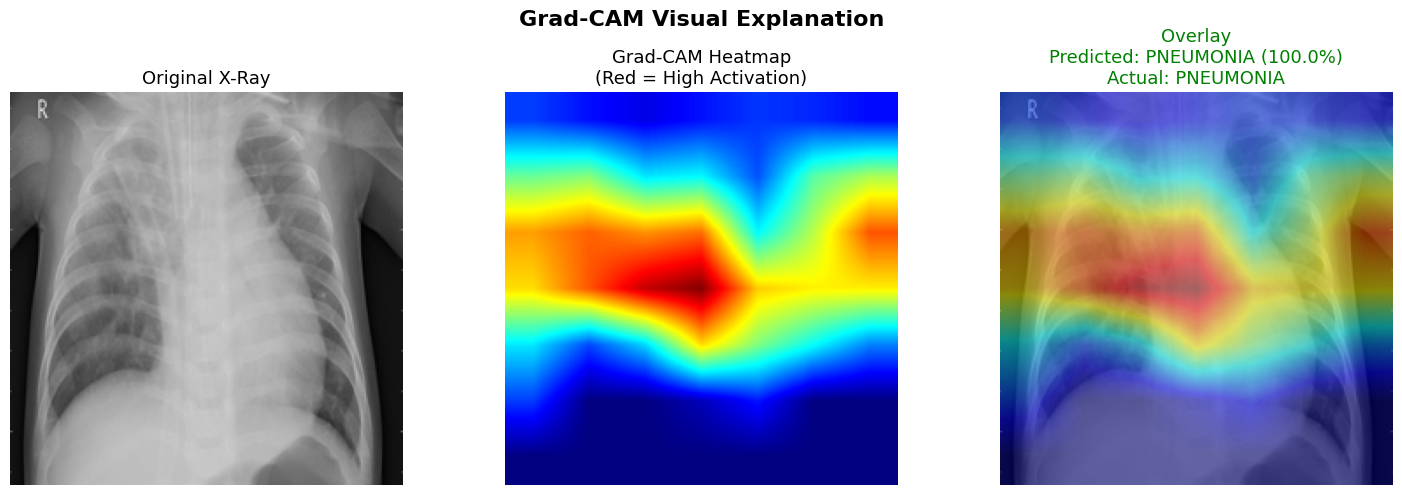

Testing on NORMAL image:


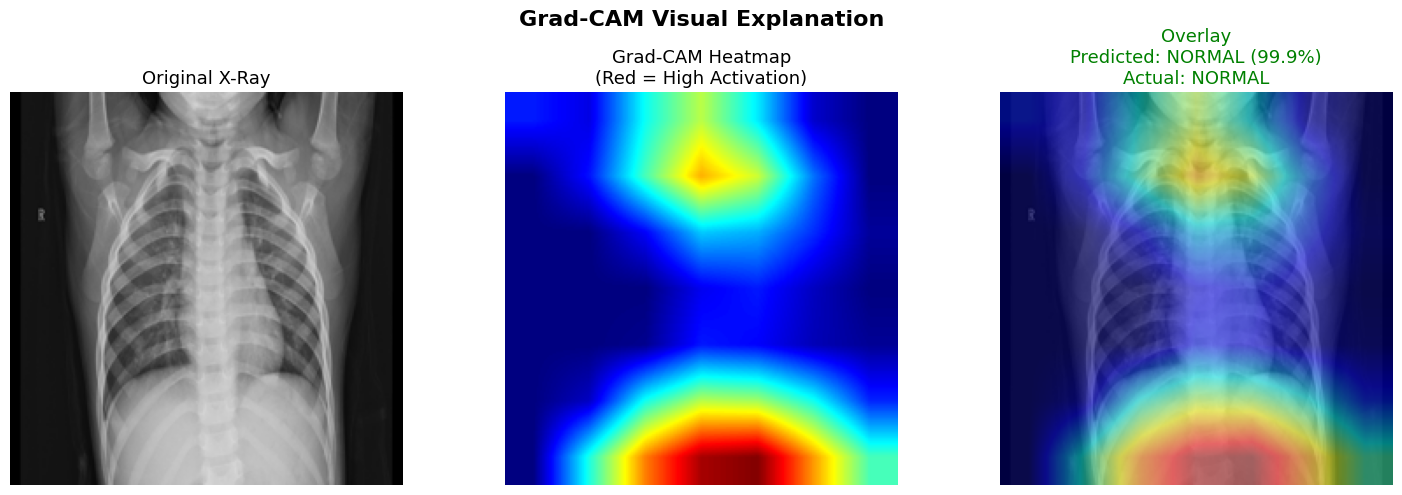

In [39]:
import random

# Test on a PNEUMONIA image
pneumonia_folder = data_path + '/test/PNEUMONIA'
pneumonia_img = random.choice(os.listdir(pneumonia_folder))
pneumonia_path = os.path.join(pneumonia_folder, pneumonia_img)

print("Testing on PNEUMONIA image:")
show_gradcam(model, pneumonia_path, true_label='PNEUMONIA')

# Test on a NORMAL image
normal_folder = data_path + '/test/NORMAL'
normal_img = random.choice(os.listdir(normal_folder))
normal_path = os.path.join(normal_folder, normal_img)

print("Testing on NORMAL image:")
show_gradcam(model, normal_path, true_label='NORMAL')

```
For PNEUMONIA image:
  Original X-Ray     → standard chest X-ray
  Heatmap            → RED/YELLOW patches on the infected lung regions
  Overlay            → heatmap on top of X-ray showing exactly
                       WHERE the model found the pneumonia

For NORMAL image:
  Heatmap            → more spread out, no concentrated red spots
  Overlay            → no specific region highlighted